In [1]:
import tenpy
# from tenpy.models.model import CouplingMPOModel
# from tenpy.networks.site import SpinHalfFermionSite
# from tenpy.networks.mps import MPS
# from tenpy.algorithms import dmrg as tenpy_dmrg
import sys
sys.path.append('..')

# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [15]:
# REQ_DATA = 't_1.00_U_0.10_Vpp_0.800/v2/'
REQ_DATA = 't_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_100/'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if "chimax_100" in f]
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
        'model_params' : model_params,
        'converged' : metadata['converged'], 
        'E' : metadata['E'], 
        'Sz' : metadata['Sz'],
        'Ntot' : metadata["Ntot"], 
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df.head()

,psi,dV,mean_Sz,mean_fill,model_params,converged,E,Sz,Ntot
14,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.0,-6.794326e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.8, 'Vpp': 0.8, 'bc...",True,-0.563028,"[-6.6102128210630205e-12, -6.978438971786054e-12]","[0.49963472391442565, 0.5003652760855741]"
6,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.1,1.496816e-13,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.9000000000000004, ...",True,-0.558356,"[1.512567186938287e-13, 1.4810651757750387e-13]","[0.49963555101088314, 0.5003644489891153]"
12,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.2,6.378394e-13,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.0, 'Vpp': 0.8, 'bc...",True,-0.553850,"[1.1556981247336767e-12, 1.1998074302957404e-13]","[0.499649151932967, 0.50035084806703]"
11,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.3,8.465927e-14,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.1000000000000005, ...",True,-0.549509,"[8.942496741357913e-14, 7.989358008700125e-14]","[0.4996500119665077, 0.5003499880334913]"
17,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.4,-5.363690e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc...",True,-0.545356,"[-5.34573800279647e-12, -5.3816412307516695e-12]","[0.5002553354386171, 0.4997446645613829]"


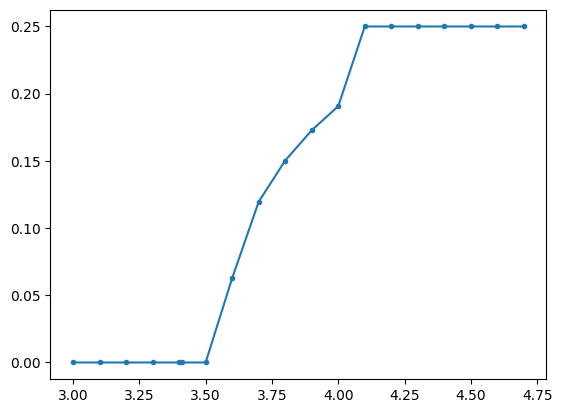

In [9]:
fig, ax = plt.subplots(1)
mask = df['converged']
ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_Sz']), ls='-', marker='.', c='C0')
ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_Sz']), ls='', marker='x', c='r')
# ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_fill']), ls='-', marker='.', c='C1')
# ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_fill']), ls='', marker='x', c='r')
# ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'E']), ls='-', marker='.', c='C2')
# ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'E']), ls='', marker='x', c='r')

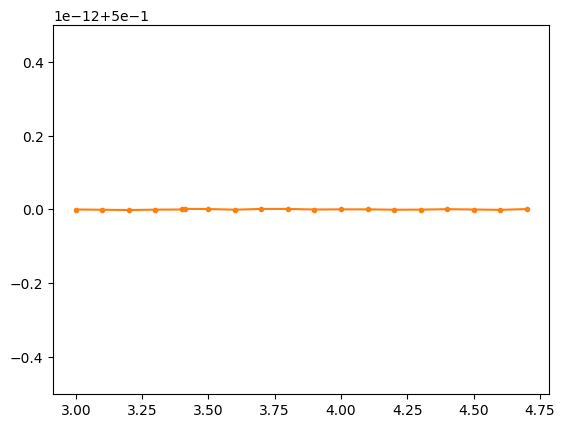

In [11]:
# plt.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'E']), ls='-', marker='.', c='C2')
# plt.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'E']), ls='', marker='x', c='r')
plt.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_fill']), ls='-', marker='.', c='C1')
plt.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_fill']), ls='', marker='x', c='r')

In [14]:
df['mean_fill']

14    0.5
6     0.5
12    0.5
11    0.5
17    0.5
2     0.5
10    0.5
16    0.5
8     0.5
7     0.5
5     0.5
18    0.5
0     0.5
1     0.5
13    0.5
15    0.5
4     0.5
3     0.5
9     0.5
Name: mean_fill, dtype: float64